# 01 Descarga, carga y limpieza del grafo

**Proyecto:** accesibilidad peatonal a equipamiento urbano – Miraflores + San Juan de Miraflores (Hito 1)

Este notebook cubre los pasos 2 a 4 del plan (`docs/hito1`):

- **Paso 2:** descarga de datos y respaldo reproducible
- Paso 3: carga e inventario
- Paso 4: limpieza y proyección

## Paso 2 – Descarga de datos

### 2.1 Configuración, semilla y versiones

In [4]:
import sys, json, hashlib, platform, datetime, time
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import shapely
import osmnx as ox
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
from src import config as cfg

np.random.seed(cfg.SEED)
ox.settings.timeout = 300
ox.settings.requests_timeout = 60   # un intento colgado no bloquea 180 s; se reintenta abajo
ox.settings.use_cache = True
ox.settings.log_console = False

for d in (cfg.DATA_RAW, cfg.DATA_INTERIM, cfg.DATA_PROCESSED):
    d.mkdir(parents=True, exist_ok=True)

versiones = {
    "python": platform.python_version(),
    "osmnx": ox.__version__,
    "networkx": nx.__version__,
    "geopandas": gpd.__version__,
    "shapely": shapely.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
}
versiones

{'python': '3.13.15',
 'osmnx': '2.1.1',
 'networkx': '3.6.1',
 'geopandas': '1.1.4',
 'shapely': '2.1.2',
 'numpy': '2.1.3',
 'pandas': '2.2.3'}

### 2.2 Límites de los distritos

In [5]:
limites = ox.geocode_to_gdf(cfg.PLACES)
limites["distrito"] = cfg.DISTRICT_LABELS
limites_utm = limites.to_crs(cfg.CRS_METRIC)
limites_utm["area_km2"] = limites_utm.geometry.area / 1e6
limites_utm[["distrito", "area_km2"]].round(2)

,distrito,area_km2
0,Miraflores,9.45
1,San Juan de Miraflores,22.06


### 2.3 Polígono de descarga

Se unen ambos distritos y se agrega un buffer de `BUFFER_M` metros (calculado en UTM, nunca en grados). Así las rutas cercanas al límite no quedan truncadas; en la limpieza se recorta lo que quede fuera de los distritos.

> **Los distritos no son contiguos** (Surco queda entre ambos), por lo que el polígono es un `MultiPolygon` de dos partes y el grafo tendrá al menos dos componentes. Por eso la descarga usa `retain_all=True`: con el valor por defecto (`False`) osmnx conserva solo el componente más grande y descarta el otro distrito completo.

Área de los distritos unidos: 31.51 km²
Área con buffer de 300 m: 45.44 km²


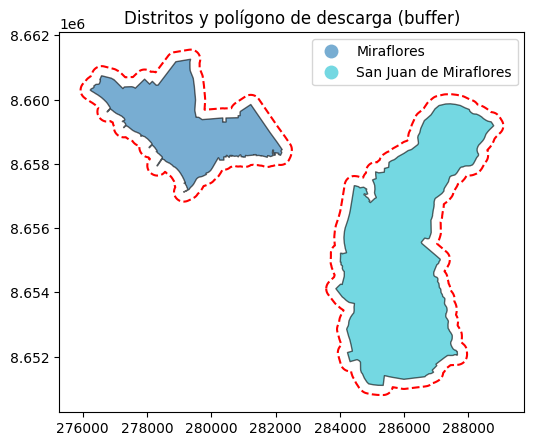

In [6]:
union_utm = limites_utm.geometry.union_all()
poligono_descarga_utm = union_utm.buffer(cfg.BUFFER_M)
poligono_descarga = gpd.GeoSeries([poligono_descarga_utm], crs=cfg.CRS_METRIC).to_crs(4326).iloc[0]

print(f"Área de los distritos unidos: {union_utm.area/1e6:.2f} km²")
print(f"Área con buffer de {cfg.BUFFER_M} m: {poligono_descarga_utm.area/1e6:.2f} km²")

ax = limites_utm.plot(column="distrito", alpha=0.6, edgecolor="k", legend=True, figsize=(6, 6))
gpd.GeoSeries([poligono_descarga_utm], crs=cfg.CRS_METRIC).boundary.plot(ax=ax, color="r", ls="--")
ax.set_title("Distritos y polígono de descarga (buffer)")
plt.show()

### 2.4 Descarga del grafo peatonal

In [7]:
# Overpass a veces tarda en conectar; se reintenta con pausa
for intento in range(1, 13):
    try:
        momento = datetime.datetime.now().astimezone()
        G_raw = ox.graph_from_polygon(poligono_descarga, network_type=cfg.NETWORK_TYPE, simplify=True, retain_all=True)
        break
    except Exception as e:
        print(f"Intento {intento} fallido: {type(e).__name__}")
        if intento == 12:
            raise
        time.sleep(5)
print(f"Descargado: {G_raw.number_of_nodes()} nodos, {G_raw.number_of_edges()} aristas")

Descargado: 17834 nodos, 52768 aristas


### 2.4b Verificación de cobertura

Se comprueba que el grafo contiene nodos de **ambos** distritos antes de guardarlo, y se registra el número de componentes conexos.

In [8]:
nodos_g = ox.graph_to_gdfs(G_raw, edges=False).to_crs(cfg.CRS_METRIC)
etiq = gpd.sjoin(nodos_g[["geometry"]], limites_utm[["distrito", "geometry"]], how="left", predicate="within")
etiq = etiq[~etiq.index.duplicated(keep="first")]["distrito"].fillna("Fuera (buffer)")
nodos_por_distrito = etiq.value_counts().to_dict()
n_componentes = nx.number_weakly_connected_components(G_raw)

print("Nodos por distrito:", nodos_por_distrito)
print("Componentes conexos (débiles):", n_componentes)
faltan = [d for d in cfg.DISTRICT_LABELS if nodos_por_distrito.get(d, 0) == 0]
assert not faltan, f"El grafo no contiene nodos de: {faltan}"

Nodos por distrito: {'San Juan de Miraflores': 9367, 'Fuera (buffer)': 4539, 'Miraflores': 3928}
Componentes conexos (débiles): 112


### 2.5 Respaldo en disco y registro de reproducibilidad

Se guarda el grafo crudo (GraphML), los límites (GeoPackage) y un log con fecha, consulta, versiones, conteos y hash SHA-256.

In [9]:
ruta_grafo = cfg.DATA_RAW / "walk_graph_raw.graphml"
ruta_limites = cfg.DATA_RAW / "limites_distritos.gpkg"
ruta_log = cfg.DATA_RAW / "descarga_log.json"

ox.save_graphml(G_raw, ruta_grafo)
limites[["distrito", "geometry"]].to_file(ruta_limites, driver="GPKG")

def sha256(ruta):
    h = hashlib.sha256()
    with open(ruta, "rb") as f:
        for bloque in iter(lambda: f.read(1 << 20), b""):
            h.update(bloque)
    return h.hexdigest()

log = {
    "fecha_descarga": momento.isoformat(timespec="seconds"),
    "consulta": {
        "funcion": "ox.graph_from_polygon",
        "lugares": cfg.PLACES,
        "network_type": cfg.NETWORK_TYPE,
        "simplify": True,
        "retain_all": True,
        "buffer_m": cfg.BUFFER_M,
        "crs_buffer": cfg.CRS_METRIC,
    },
    "versiones": versiones,
    "grafo_crudo": {
        "archivo": ruta_grafo.name,
        "nodos": G_raw.number_of_nodes(),
        "aristas": G_raw.number_of_edges(),
        "componentes_debiles": n_componentes,
        "nodos_por_distrito": nodos_por_distrito,
        "sha256": sha256(ruta_grafo),
    },
    "limites": {"archivo": ruta_limites.name, "sha256": sha256(ruta_limites)},
}
ruta_log.write_text(json.dumps(log, indent=2, ensure_ascii=False), encoding="utf-8")
print(json.dumps(log, indent=2, ensure_ascii=False))

{
  "fecha_descarga": "2026-10-03T21:50:17+00:00",
  "consulta": {
    "funcion": "ox.graph_from_polygon",
    "lugares": [
      "Miraflores, Lima, Peru",
      "San Juan de Miraflores, Lima, Peru"
    ],
    "network_type": "walk",
    "simplify": true,
    "retain_all": true,
    "buffer_m": 300,
    "crs_buffer": "EPSG:32718"
  },
  "versiones": {
    "python": "3.13.15",
    "osmnx": "2.1.1",
    "networkx": "3.6.1",
    "geopandas": "1.1.4",
    "shapely": "2.1.2",
    "numpy": "2.1.3",
    "pandas": "2.2.3"
  },
  "grafo_crudo": {
    "archivo": "walk_graph_raw.graphml",
    "nodos": 17834,
    "aristas": 52768,
    "componentes_debiles": 112,
    "nodos_por_distrito": {
      "San Juan de Miraflores": 9367,
      "Fuera (buffer)": 4539,
      "Miraflores": 3928
    },
    "sha256": "32ea579d862a9b372905e3881c2b2278908407fdb4bb83b0a657dded43e5f36e"
  },
  "limites": {
    "archivo": "limites_distritos.gpkg",
    "sha256": "ad431d8e650c39decedd5539ba0c3df582824f41ececd2f6eca87fc6

## Carga e inventario del grafo

Se trabaja siempre desde el archivo en disco (`data/raw`), no desde la API, para que los resultados no dependan de la fecha de consulta.

### Carga y estructura general

In [2]:
ruta_grafo = cfg.DATA_RAW / "walk_graph_raw.graphml"
ruta_limites = cfg.DATA_RAW / "limites_distritos.gpkg"

G = ox.load_graphml(ruta_grafo)
limites = gpd.read_file(ruta_limites)

print("Tipo de grafo:", type(G).__name__)
print("CRS del grafo:", G.graph.get("crs"))
print(f"Nodos: {G.number_of_nodes():,} | Aristas: {G.number_of_edges():,}")
print("Atributos de nodos:", sorted({k for _, d in G.nodes(data=True) for k in d}))

nodos, aristas = ox.graph_to_gdfs(G)
print("\nColumnas de aristas:", [c for c in aristas.columns])

Tipo de grafo: MultiDiGraph
CRS del grafo: epsg:4326
Nodos: 17,834 | Aristas: 52,768
Atributos de nodos: ['highway', 'railway', 'street_count', 'x', 'y']



Columnas de aristas: ['osmid', 'highway', 'maxspeed', 'name', 'oneway', 'reversed', 'length', 'lanes', 'geometry', 'access', 'service', 'tunnel', 'junction', 'width', 'bridge']


### Estructura de las aristas: bucles, paralelas y simetría

In [3]:
n_bucles = nx.number_of_selfloops(G)
n_paralelas = int((aristas.index.get_level_values("key") > 0).sum())

# Simetría: ¿cada arista u->v tiene su inversa v->u?
pares = set(zip(aristas.index.get_level_values("u"), aristas.index.get_level_values("v")))
con_inversa = sum((v, u) in pares for u, v in pares)
print(f"Bucles (self-loops): {n_bucles}")
print(f"Aristas paralelas (key > 0): {n_paralelas}")
print(f"Pares dirigidos únicos: {len(pares):,} | con arista inversa: {con_inversa:,} ({con_inversa/len(pares):.1%})")
print("Valores de 'oneway':", aristas["oneway"].astype(str).value_counts().to_dict())

Bucles (self-loops): 70
Aristas paralelas (key > 0): 425
Pares dirigidos únicos: 52,343 | con arista inversa: 52,343 (100.0%)
Valores de 'oneway': {'False': 52768}


### Tipos de vía (`highway`)

Las aristas simplificadas pueden traer listas de valores; se cuentan por separado.

In [4]:
hw = aristas["highway"].apply(lambda v: v if isinstance(v, list) else [v])
print(f"Aristas con más de un tipo de vía (lista): {(hw.str.len() > 1).sum():,}\n")
conteo_hw = hw.explode().value_counts()
pd.DataFrame({"aristas": conteo_hw, "%": (conteo_hw / conteo_hw.sum() * 100).round(1)})

Aristas con más de un tipo de vía (lista): 640



,aristas,%
highway,,
residential,22056,41.3
footway,15938,29.8
secondary,3886,7.3
tertiary,3040,5.7
service,2460,4.6
steps,2362,4.4
primary,966,1.8
path,902,1.7
pedestrian,480,0.9


### Nodos por distrito

El grafo se descargó con un buffer de 300 m, por lo que una parte de los nodos cae fuera de ambos distritos. Se etiquetan por join espacial para saber cuántos hay en cada uno (la etiqueta definitiva se asigna en la limpieza).

In [5]:
nodos_utm = nodos.to_crs(cfg.CRS_METRIC)
limites_utm = limites.to_crs(cfg.CRS_METRIC)
etiqueta = gpd.sjoin(nodos_utm[["geometry"]], limites_utm[["distrito", "geometry"]], how="left", predicate="within")
etiqueta = etiqueta[~etiqueta.index.duplicated(keep="first")]["distrito"].fillna("Fuera (buffer)")
tabla_distrito = etiqueta.value_counts().rename("nodos").to_frame()
tabla_distrito["%"] = (tabla_distrito["nodos"] / tabla_distrito["nodos"].sum() * 100).round(1)
tabla_distrito

,nodos,%
distrito,,
San Juan de Miraflores,9367,52.5
Fuera (buffer),4539,25.5
Miraflores,3928,22.0


### Componentes conexos

Los dos distritos no son contiguos, así que se esperan dos componentes grandes y varios fragmentos pequeños. Para cada componente se indica en qué zona cae la mayoría de sus nodos.

In [6]:
comps = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
filas = []
for k, c in enumerate(comps, start=1):
    zona = etiqueta.reindex(list(c)).value_counts()
    filas.append({"componente": k, "nodos": len(c), "zona_mayoritaria": zona.index[0], "% en esa zona": round(zona.iloc[0] / len(c) * 100, 1)})
tabla_comp = pd.DataFrame(filas)
print(f"Componentes: {len(comps)} | nodos en los dos mayores: {tabla_comp['nodos'].head(2).sum():,} ({tabla_comp['nodos'].head(2).sum() / G.number_of_nodes():.1%})")
print(f"Fragmentos pequeños (resto): {len(comps) - 2} componentes, {tabla_comp['nodos'].iloc[2:].sum()} nodos, el mayor de {tabla_comp['nodos'].iloc[2]} nodos")
tabla_comp.head(5)

Componentes: 112 | nodos en los dos mayores: 17,265 (96.8%)
Fragmentos pequeños (resto): 110 componentes, 569 nodos, el mayor de 39 nodos


,componente,nodos,zona_mayoritaria,% en esa zona
0,1,11465,San Juan de Miraflores,79.6
1,2,5800,Miraflores,66.2
2,3,39,Fuera (buffer),100.0
3,4,34,Fuera (buffer),100.0
4,5,25,San Juan de Miraflores,100.0


### Datos faltantes en aristas

El enunciado exige reportar el porcentaje de aristas sin `maxspeed`, `lanes` y `name`. Se calcula para todas las columnas de atributos (un valor tipo lista cuenta como presente).

In [7]:
atributos = [c for c in aristas.columns if c not in ("geometry",)]
faltantes = aristas[atributos].isna().mean().mul(100).round(1).rename("% faltante")
tabla_faltantes = faltantes.to_frame().assign(aristas_con_dato=lambda d: ((100 - d["% faltante"]) / 100 * len(aristas)).round().astype(int))
tabla_faltantes.sort_values("% faltante", ascending=False)

,% faltante,aristas_con_dato
junction,99.9,53
tunnel,99.8,106
bridge,99.6,211
access,99.5,264
width,99.5,264
service,98.9,580
maxspeed,76.9,12189
lanes,70.0,15830
name,52.8,24906
highway,0.0,52768


In [8]:
# Faltantes de los tres atributos pedidos, por distrito de la arista (según su nodo de origen)
u = aristas.index.get_level_values("u")
aristas_dist = pd.Series(etiqueta.reindex(u).values, index=aristas.index, name="distrito")
clave = ["name", "maxspeed", "lanes"]
por_distrito = (aristas[clave].isna().groupby(aristas_dist.values).mean() * 100).round(1)
por_distrito.columns = [f"% sin {c}" for c in clave]
por_distrito.assign(aristas=aristas_dist.value_counts())

,% sin name,% sin maxspeed,% sin lanes,aristas
Fuera (buffer),48.8,75.2,68.4,12596
Miraflores,44.2,51.2,51.8,11685
San Juan de Miraflores,58.2,88.1,78.2,28487


### Distribución de longitudes de arista (m)

Longitudes en el CRS original se calculan por el atributo `length` que provee osmnx (en metros).

In [9]:
aristas["length"].describe().round(2).to_frame("length (m)")

,length (m)
count,52768.00
mean,47.03
std,50.88
min,0.11
25%,15.01
50%,37.26
75%,59.84
max,2432.36


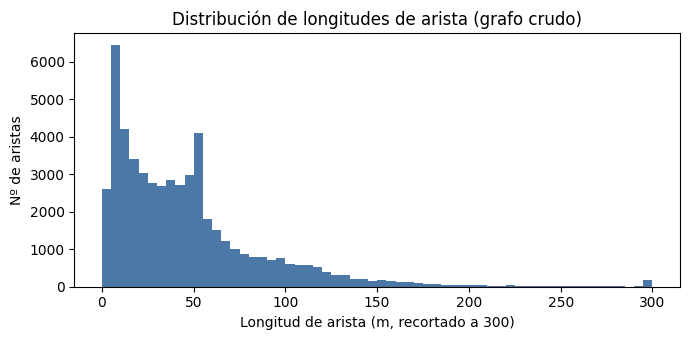

In [10]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(aristas["length"].clip(upper=300), bins=60, color="#4c78a8")
ax.set_xlabel("Longitud de arista (m, recortado a 300)")
ax.set_ylabel("Nº de aristas")
ax.set_title("Distribución de longitudes de arista (grafo crudo)")
plt.tight_layout()
plt.show()

### Hallazgos del inventario

- **Tamaño:** 17 834 nodos y 52 768 aristas; cumple los mínimos (3 000 / 6 000) y el tope recomendado (60 000).
- **Simetría:** `oneway` es falso en el 100 % de las aristas y todas tienen su inversa, así que el grafo peatonal es en la práctica no dirigido.
- **Componentes:** 112; los dos mayores (SJM y Miraflores, cada uno con su buffer) reúnen el 96.8 % de los nodos. Los otros 110 son fragmentos de 39 nodos o menos (569 nodos en total) y se tratarán en la limpieza.
- **Buffer:** el 25.5 % de los nodos queda fuera de ambos distritos y debe recortarse o etiquetarse antes de calcular métricas por distrito.
- **Tipos de vía:** `residential` (41.3 %) y `footway` (29.8 %) dominan; hay 4.4 % de escaleras (`steps`), relevante para la accesibilidad en SJM.
- **Datos faltantes:** `maxspeed` 76.9 %, `lanes` 70.0 % y `name` 52.8 %; peor en SJM (88.1 %, 78.2 %, 58.2 %) que en Miraflores (51.2 %, 51.8 %, 44.2 %). No se imputan, porque el análisis peatonal usa una velocidad de caminata constante.
- **Anomalías por revisar:** 70 bucles, 425 aristas paralelas, longitudes desde 0.11 m hasta 2 432 m (posibles outliers), y 640 aristas con `highway` en forma de lista.